In [3]:
## Load libraries
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from keras.datasets import  mnist
plt.style.use('dark_background')
%matplotlib inline

In [4]:
np.set_printoptions(precision=2)
import tensorflow as tf
tf.__version__

'2.14.0'

In [5]:
#Load MNIST data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.transpose(1, 2, 0)
X_test = X_test.transpose(1, 2, 0)
X_train = X_train.reshape(X_train.shape[0] * X_train.shape[1], X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0] * X_test.shape[1], X_test.shape[2])


In [6]:
num_labels = len(np.unique(y_train))
num_features = X_train.shape[0]
num_samples = X_train.shape[1]

In [7]:
#One hot encode class labels
Y_train = tf.keras.utils.to_categorical(y_train).T
Y_test = tf.keras.utils.to_categorical(y_test).T


In [8]:
#Normalizze the samples (images)
xmax = np.amax(X_train)
xmin = np.amin(X_train)
X_train = (X_train - xmin)/(xmax - xmin) #all train features turn into a number between 1 and 0
X_test = (X_test - xmin)/(xmax - xmin) 

In [9]:
print('MNIST set')
print('----------')
print('Number of training samples = %d'%(num_samples))
print('Number of features = %d'%(num_features))
print('Number of output classes = %d'%(num_labels))

MNIST set
----------
Number of training samples = 60000
Number of features = 784
Number of output classes = 10


In [10]:
class Layer:
  def __init__(self):
    self.input = None
    self.output = None

  def forward(self, input):
    pass

  def backward(self, output_gradient, learning_rate):
    pass

In [11]:
## Define the loss function and its gradient
def cce(Y, Yhat):
  return(np.mean(np.sum(-Y*np.log(Yhat), axis=0)))

def cce_gradient(Y, Yhat):
  return(-Y/Yhat)

# TensorFlow in-built function for categorical crossentropy loss
#cce = tf.keras.losses.CategoricalCrossentropy()

In [12]:
class Softmax(Layer):
    def forward(self, input):
        self.input = input  # Assign the input to self.input
        self.output = tf.nn.softmax(self.input, axis=0).numpy()

    def backward(self, output_gradient, learning_rate=None):
        # Following is the inefficient way of calculating the backward gradient
        softmax_gradient = np.empty((self.input.shape[0], output_gradient.shape[1]), dtype=np.float64)
        for b in range(softmax_gradient.shape[1]):
            softmax_gradient[:, b] = np.dot((np.identity(self.output.shape[0]) - self.output[:, b].reshape(-1, 1).T) * self.output[:, b].reshape(-1, 1),
                                            output_gradient[:, b])
        return softmax_gradient


In [13]:
## Dense layer class
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.weights = np.empty((output_size, input_size + 1), dtype=np.float64) # +1 for bias trick
        self.weights[:, :-1]  = 0.01 * np.random.randn(output_size, input_size) # 
        self.weights[:, -1] = 0.01 # Set all bias values to the same nonzero constant

    def forward(self, input):
        self.input = np.vstack([input, np.ones((1, input.shape[1]))]) #bias trick
        self.output = np.dot(self.weights, self.input)

    def backward(self, output_gradient, learning_rate=None):
        dense_gradient = np.zeros((self.output.shape[0], self.input.shape[0]), dtype=np.float64)
        for b in range(output_gradient.shape[1]):
            dense_gradient += np.dot(output_gradient[:, b].reshape(-1, 1), self.input[:, b].reshape(1, -1))
        # dense_gradient = np.mean(dense_gradient, axis=1)
        dense_gradient = 1 / output_gradient.shape[1] * dense_gradient
        self.weights -= learning_rate * dense_gradient
        # self.weights[:, :-1] -= learning_rate * dense_gradient[:, :-1]
        # self.weights[:, -1] -= learning_rate * dense_gradient[:, -1]

        return np.dot(self.weights.T, output_gradient)

        ## Following is the efficient way of calculating the backward gradient
        #dense_gradient = (1/output_gradient.shape[1])1])*np.dot(np.atleast_2d(output_gradient), np.atleast_2d(self.input).T)
        #self.weights = learning_rate * (-dense_gradient)

In [14]:
#Function to generate sample indices for batch processing according to batch size
def generate_batch_indices(num_samples, batch_size):
    #reorder sample indices
    reordered_sample_indices= np.random.choice(num_samples, num_samples, replace=False)
    #Generate batch indices for batch processing
    batch_indices = np.split(reordered_sample_indices, np.arange(batch_size, len(reordered_sample_indices), batch_size))
    return batch_indices

In [15]:
# #Example generation of batch indices
# num_samples = 64
# batch_size = 8
# batch_indices = generate_batch_indices(num_samples, batch_size)
# print(batch_indices)

In [16]:
#Train the 0-layer neural network using batch training with batch size = 16
learning_rate = 1e-2
batch_size = 200
nepochs = 20
loss_epoch = np.empty(nepochs,dtype=np.float64) #create empty array to store loss values for each epoch


In [17]:
Z = np.arange(6).reshape(2, -1).astype(np.float64)
print(Z)
tf.nn.softmax(Z).numpy()

[[0. 1. 2.]
 [3. 4. 5.]]


array([[0.09, 0.24, 0.67],
       [0.09, 0.24, 0.67]])

In [18]:
#Neural network architecture
dlayer = Dense(num_features, num_labels)
softmax = Softmax()

In [19]:
epoch = 0
while epoch < nepochs:
    batch_indices = generate_batch_indices(num_samples, batch_size)
    loss = 0
    for b in range(len(batch_indices)):
        dlayer.forward(X_train[:, batch_indices[b]])
        softmax.forward(dlayer.output)
        loss += cce(Y_train[:, batch_indices[b]], softmax.output)

        # backward prop starts here
        grad = cce_gradient(Y_train[:, batch_indices[b]], softmax.output)
        grad = softmax.backward(grad)
        grad = dlayer.backward(grad, learning_rate)

    loss_epoch[epoch] = loss/len(batch_indices)
    print('Epoch %d: loss = %f'%(epoch+1, loss_epoch[epoch]))
    epoch = epoch + 1

Epoch 1: loss = 1.446334
Epoch 2: loss = 0.849256
Epoch 3: loss = 0.682785
Epoch 4: loss = 0.601907
Epoch 5: loss = 0.552629
Epoch 6: loss = 0.518927
Epoch 7: loss = 0.494084
Epoch 8: loss = 0.474864
Epoch 9: loss = 0.459412
Epoch 10: loss = 0.446653
Epoch 11: loss = 0.435842
Epoch 12: loss = 0.426596
Epoch 13: loss = 0.418573
Epoch 14: loss = 0.411483
Epoch 15: loss = 0.405162
Epoch 16: loss = 0.399510
Epoch 17: loss = 0.394405
Epoch 18: loss = 0.389746
Epoch 19: loss = 0.385493
Epoch 20: loss = 0.381552


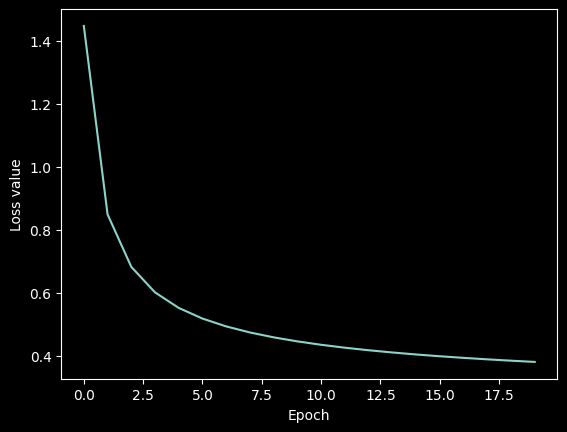

In [20]:
##Plot training loss as a function of epoch
plt.plot(loss_epoch)
plt.xlabel('Epoch')
plt.ylabel('Loss value')
plt.show()

In [21]:
#Accuracy on test set
dlayer.forward(X_test)
softmax.forward(dlayer.output)
ypred = np.argmax(softmax.output.T, axis=1)
print(ypred)
ytrue = np.argmax(Y_test.T, axis=1)
print(ytrue)
np.mean(ytrue==ypred)

[7 2 1 ... 4 5 6]
[7 2 1 ... 4 5 6]


0.9045

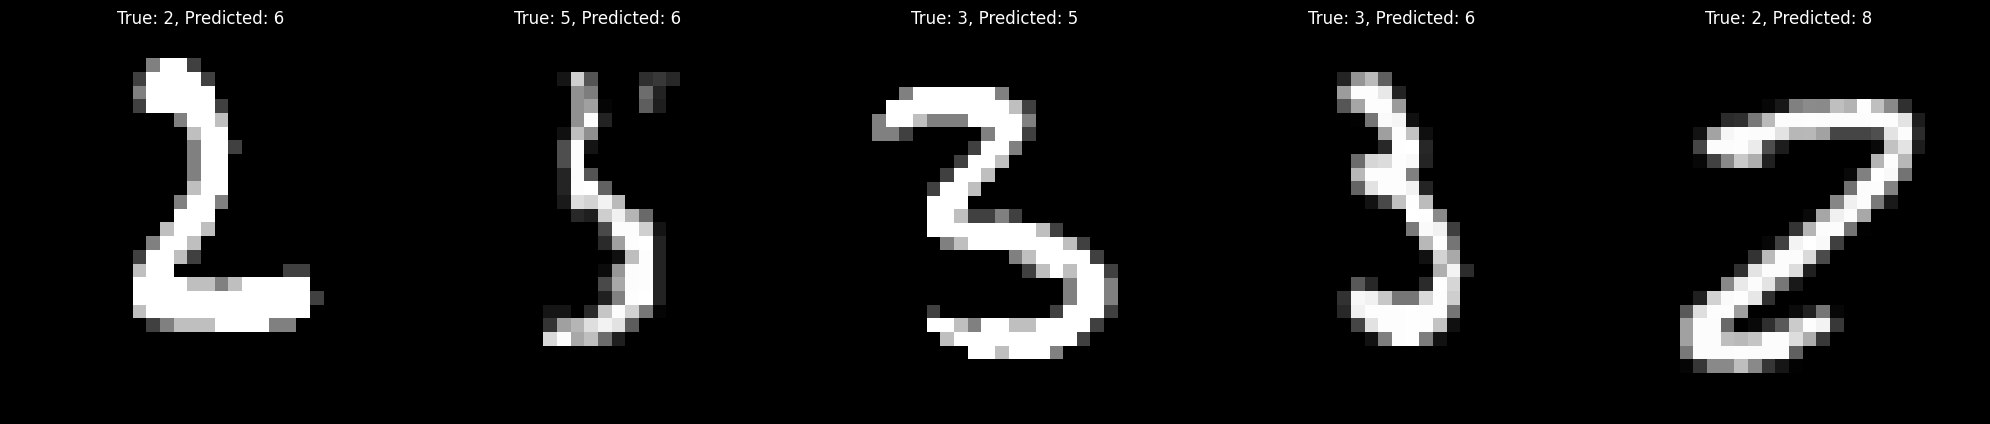

In [22]:
class misclassified_images:
    def plot_misclassified_images(X_test, ytrue, ypred, num_images=5):
        misclassified_indices = np.where(ytrue != ypred)[0]
        random_misclassified_indices = np.random.choice(misclassified_indices, num_images, replace=False)
        
        fig, axes = plt.subplots(1, num_images, figsize=(20, 5))
        for i, index in enumerate(random_misclassified_indices):
            axes[i].imshow(X_test[:, index].reshape(28, 28), cmap='gray')
            axes[i].set_title(f"True: {ytrue[index]}, Predicted: {ypred[index]}")
            axes[i].axis('off')
        plt.tight_layout()
        plt.show()

    miss_classified = plot_misclassified_images(X_test, ytrue, ypred)

    def plot_images_side_by_side(original_images, misclassified_images):
        num_images = len(original_images)
        fig, axes = plt.subplots(1, num_images, figsize=(20, 5))
        
        for i in range(num_images):
            axes[i].imshow(original_images[i].reshape(28, 28), cmap='gray')
            axes[i].set_title(f"Original: {i}")
            axes[i].axis('off')
            
        fig, axes = plt.subplots(1, num_images, figsize=(20, 5))
        
        for i in range(num_images):
            axes[i].imshow(misclassified_images[i].reshape(28, 28), cmap='gray')
            axes[i].set_title(f"Misclassified: {i}")
            axes[i].axis('off')
            
        plt.tight_layout()
        plt.show()


In [23]:
class MisclassifiedImages:
    def plot_misclassified_images(X_test, ytrue, ypred, num_images=5):
        misclassified_indices = np.where(ytrue != ypred)[0]
        random_misclassified_indices = np.random.choice(misclassified_indices, num_images, replace=False)
        
        fig, axes = plt.subplots(1, num_images, figsize=(20, 5))
        for i, index in enumerate(random_misclassified_indices):
            axes[i].imshow(X_test[:, index].reshape(28, 28), cmap='gray')
            axes[i].set_title(f"True: {ytrue[index]}, Predicted: {ypred[index]}")
            axes[i].axis('off')
        plt.tight_layout()
        plt.show()

    def plot_images_side_by_side(original_images, misclassified_images):
        num_images = len(original_images)
        fig, axes = plt.subplots(1, 2 * num_images, figsize=(20, 5))
        
        for i in range(num_images):
            axes[i].imshow(original_images[i].reshape(28, 28), cmap='gray')
            axes[i].set_title(f"Original: {i}")
            axes[i].axis('off')
            
            axes[i + num_images].imshow(misclassified_images[i].reshape(28, 28), cmap='gray')
            axes[i + num_images].set_title(f"Misclassified: {i}")
            axes[i + num_images].axis('off')
            
        plt.tight_layout()
        plt.show()

# Assuming you have the following arrays defined
# X_test, y_true, y_pred
# misclassified_images

# Get the actual misclassified images using indices
misclassified_image_data = X_test[:, misclassified_images]

# Call the static methods with your data
MisclassifiedImages.plot_misclassified_images(X_test, ytrue, ypred)
MisclassifiedImages.plot_images_side_by_side(X_test[:, misclassified_images], misclassified_image_data)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices